In [21]:
# ============================================================
# 05_realized_variance_and_vrp_v0_1
#
# Goal:
#   Build realized variance and first VRP panel using:
#     - final repaired VIX-style implied variance term structure
#     - SPX closes from FRED
# ============================================================

from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if current_dir.name.lower() == "notebooks":
    PROJECT_ROOT = current_dir.parent
else:
    PROJECT_ROOT = current_dir

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
EXTERNAL_DATA_DIR = DATA_DIR / "external"
AUDIT_DIR = DATA_DIR / "audit"

EXTERNAL_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_TENOR_DAYS = [9, 12, 15, 18, 21, 24, 27, 30, 33]

IMPLIED_PARQUET = PROCESSED_DATA_DIR / "vix_term_structure_history_v0_7_1_repaired_total_variance.parquet"

SPX_FRED_CSV = EXTERNAL_DATA_DIR / "spx_index_daily_fred.csv"
SPX_STOOQ_CSV = EXTERNAL_DATA_DIR / "spx_index_daily_stooq_backup.csv"

print("Project root:", PROJECT_ROOT)
print("Implied file exists:", IMPLIED_PARQUET.exists())
print("FRED SPX file exists:", SPX_FRED_CSV.exists())
print("Stooq SPX backup file exists:", SPX_STOOQ_CSV.exists())

Project root: C:\Users\patri\vrp_project
Implied file exists: True
FRED SPX file exists: True
Stooq SPX backup file exists: False


In [22]:
# ============================================================
# Download / refresh SPX daily closes from FRED
# ============================================================

FRED_SP500_URL = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=SP500"

force_refresh_fred_spx = True

if SPX_FRED_CSV.exists() and not force_refresh_fred_spx:
    spx_raw_df = pd.read_csv(SPX_FRED_CSV)
else:
    spx_raw_df = pd.read_csv(FRED_SP500_URL)
    spx_raw_df.to_csv(SPX_FRED_CSV, index=False)

print("Saved/read FRED SPX file:", SPX_FRED_CSV)
display(spx_raw_df.head())
display(spx_raw_df.tail())
print(spx_raw_df.dtypes)

Saved/read FRED SPX file: C:\Users\patri\vrp_project\data\external\spx_index_daily_fred.csv


,observation_date,SP500
0,2016-06-27,2000.54
1,2016-06-28,2036.09
2,2016-06-29,2070.77
3,2016-06-30,2098.86
4,2016-07-01,2102.95


,observation_date,SP500
2605,2026-06-22,7472.79
2606,2026-06-23,7365.46
2607,2026-06-24,7358.22
2608,2026-06-25,7357.49
2609,2026-06-26,7354.02


observation_date     object
SP500               float64
dtype: object


In [23]:
# ============================================================
# Normalize FRED SPX close file
# ============================================================

spx_df = spx_raw_df.copy()
spx_df.columns = [str(c).strip() for c in spx_df.columns]

# FRED usually returns columns: observation_date, SP500
date_col = "observation_date" if "observation_date" in spx_df.columns else "DATE"
price_col = "SP500"

if price_col not in spx_df.columns:
    raise ValueError(f"Could not find SP500 column. Columns: {list(spx_df.columns)}")

spx_df["date"] = pd.to_datetime(spx_df[date_col])
spx_df["trade_date"] = spx_df["date"].dt.strftime("%Y%m%d").astype(int)
spx_df["spx_close"] = pd.to_numeric(spx_df[price_col], errors="coerce")

spx_df = (
    spx_df[["trade_date", "date", "spx_close"]]
    .dropna()
    .drop_duplicates("trade_date")
    .sort_values("trade_date")
    .reset_index(drop=True)
)

spx_df["log_return"] = np.log(spx_df["spx_close"] / spx_df["spx_close"].shift(1))

print("Rows:", len(spx_df))
print("Date range:", spx_df["trade_date"].min(), "to", spx_df["trade_date"].max())
print("Missing closes:", spx_df["spx_close"].isna().sum())
print("Missing returns:", spx_df["log_return"].isna().sum())

display(spx_df.head())
display(spx_df.tail())

Rows: 2514
Date range: 20160627 to 20260626
Missing closes: 0
Missing returns: 1


,trade_date,date,spx_close,log_return
0,20160627,2016-06-27,2000.54,NaN
1,20160628,2016-06-28,2036.09,0.017614
2,20160629,2016-06-29,2070.77,0.016889
3,20160630,2016-06-30,2098.86,0.013474
4,20160701,2016-07-01,2102.95,0.001947


,trade_date,date,spx_close,log_return
2509,20260622,2026-06-22,7472.79,-0.003712
2510,20260623,2026-06-23,7365.46,-0.014467
2511,20260624,2026-06-24,7358.22,-0.000983
2512,20260625,2026-06-25,7357.49,-0.000099
2513,20260626,2026-06-26,7354.02,-0.000472


In [24]:
# ============================================================
# Load implied term structure and check SPX close coverage
# ============================================================

implied_df = pd.read_parquet(IMPLIED_PARQUET).copy()

print("Implied rows:", len(implied_df))
print("Implied date range:", implied_df["trade_date"].min(), "to", implied_df["trade_date"].max())

implied_dates = sorted(implied_df["trade_date"].unique())
spx_dates = set(spx_df["trade_date"])

missing_spx_dates = [d for d in implied_dates if d not in spx_dates]

print("Unique implied dates:", len(implied_dates))
print("Missing SPX close dates:", len(missing_spx_dates))

if len(missing_spx_dates) > 0:
    print("First missing dates:")
    print(missing_spx_dates[:20])

Implied rows: 18099
Implied date range: 20180625 to 20260625
Unique implied dates: 2011
Missing SPX close dates: 0


In [25]:
# ============================================================
# Save normalized FRED SPX close file
# ============================================================

SPX_FRED_NORMALIZED_CSV = EXTERNAL_DATA_DIR / "spx_index_daily_fred_normalized.csv"

spx_df.to_csv(SPX_FRED_NORMALIZED_CSV, index=False)

print("Saved normalized SPX close file:", SPX_FRED_NORMALIZED_CSV)
print("Rows:", len(spx_df))
print("Date range:", spx_df["trade_date"].min(), "to", spx_df["trade_date"].max())

display(spx_df.head())
display(spx_df.tail())

Saved normalized SPX close file: C:\Users\patri\vrp_project\data\external\spx_index_daily_fred_normalized.csv
Rows: 2514
Date range: 20160627 to 20260626


,trade_date,date,spx_close,log_return
0,20160627,2016-06-27,2000.54,NaN
1,20160628,2016-06-28,2036.09,0.017614
2,20160629,2016-06-29,2070.77,0.016889
3,20160630,2016-06-30,2098.86,0.013474
4,20160701,2016-07-01,2102.95,0.001947


,trade_date,date,spx_close,log_return
2509,20260622,2026-06-22,7472.79,-0.003712
2510,20260623,2026-06-23,7365.46,-0.014467
2511,20260624,2026-06-24,7358.22,-0.000983
2512,20260625,2026-06-25,7357.49,-0.000099
2513,20260626,2026-06-26,7354.02,-0.000472


In [26]:
# ============================================================
# Calendar-day realized variance functions
# ============================================================

def realized_variance_over_calendar_window(
    returns_df,
    trade_date,
    tenor_days,
    direction,
):
    """
    Compute annualized realized variance over a calendar-day window.

    direction = "trailing":
        uses returns with return dates > trade_date - tenor_days
        and <= trade_date.

    direction = "forward":
        uses returns with return dates > trade_date
        and <= trade_date + tenor_days.

    Annualization uses calendar time:
        RV = sum(log_return^2) / (tenor_days / 365)
    """
    trade_ts = pd.to_datetime(str(int(trade_date)), format="%Y%m%d")

    if direction == "trailing":
        start_ts = trade_ts - pd.Timedelta(days=int(tenor_days))
        end_ts = trade_ts

        window = returns_df[
            (returns_df["date"] > start_ts)
            & (returns_df["date"] <= end_ts)
        ].copy()

    elif direction == "forward":
        start_ts = trade_ts
        end_ts = trade_ts + pd.Timedelta(days=int(tenor_days))

        window = returns_df[
            (returns_df["date"] > start_ts)
            & (returns_df["date"] <= end_ts)
        ].copy()

    else:
        raise ValueError("direction must be 'trailing' or 'forward'")

    squared_return_sum = np.square(window["log_return"].dropna()).sum()
    num_returns = window["log_return"].dropna().shape[0]

    annualized_variance = squared_return_sum / (tenor_days / 365.0)
    annualized_vol = np.sqrt(annualized_variance) * 100

    return {
        "realized_variance": annualized_variance,
        "realized_vol": annualized_vol,
        "realized_num_returns": num_returns,
    }

In [27]:
# ============================================================
# Build realized variance panel for all implied dates and tenors
# ============================================================

implied_dates = sorted(implied_df["trade_date"].unique())

rv_rows = []

for i, trade_date in enumerate(implied_dates, start=1):
    if i % 250 == 0:
        print(f"Processing {i}/{len(implied_dates)}: {trade_date}")

    for tenor in TARGET_TENOR_DAYS:
        trailing = realized_variance_over_calendar_window(
            returns_df=spx_df,
            trade_date=trade_date,
            tenor_days=tenor,
            direction="trailing",
        )

        forward = realized_variance_over_calendar_window(
            returns_df=spx_df,
            trade_date=trade_date,
            tenor_days=tenor,
            direction="forward",
        )

        rv_rows.append({
            "trade_date": trade_date,
            "target_days": tenor,

            "trailing_realized_variance": trailing["realized_variance"],
            "trailing_realized_vol": trailing["realized_vol"],
            "trailing_realized_num_returns": trailing["realized_num_returns"],

            "forward_realized_variance": forward["realized_variance"],
            "forward_realized_vol": forward["realized_vol"],
            "forward_realized_num_returns": forward["realized_num_returns"],
        })

realized_df = pd.DataFrame(rv_rows)

print("Realized rows:", len(realized_df))
print("Expected rows:", len(implied_dates) * len(TARGET_TENOR_DAYS))
display(realized_df.head())
display(realized_df.tail())

Processing 250/2011: 20190621
Processing 500/2011: 20200618
Processing 750/2011: 20210616
Processing 1000/2011: 20220613
Processing 1250/2011: 20230612
Processing 1500/2011: 20240610
Processing 1750/2011: 20250610
Processing 2000/2011: 20260609
Realized rows: 18099
Expected rows: 18099


,trade_date,target_days,trailing_realized_variance,trailing_realized_vol,trailing_realized_num_returns,forward_realized_variance,forward_realized_vol,forward_realized_num_returns
0,20180625,9,0.010491,10.242504,6,0.006165,7.851987,6
1,20180625,12,0.008085,8.991663,8,0.009035,9.505109,8
2,20180625,15,0.006966,8.346020,11,0.009398,9.694309,10
3,20180625,18,0.006002,7.747385,12,0.010422,10.208696,13
4,20180625,21,0.006427,8.016921,15,0.008951,9.461139,14


,trade_date,target_days,trailing_realized_variance,trailing_realized_vol,trailing_realized_num_returns,forward_realized_variance,forward_realized_vol,forward_realized_num_returns
18094,20260625,21,0.036819,19.188272,14,0.000004,0.196670,1
18095,20260625,24,0.033324,18.254779,17,0.000003,0.183968,1
18096,20260625,27,0.029714,17.237747,18,0.000003,0.173447,1
18097,20260625,30,0.027201,16.492630,21,0.000003,0.164546,1
18098,20260625,33,0.025138,15.854990,22,0.000002,0.156889,1


In [28]:
# ============================================================
# Build first VRP panel
# ============================================================

vrp_df = implied_df.merge(
    realized_df,
    on=["trade_date", "target_days"],
    how="left",
    validate="one_to_one",
)

# Main ex-ante VRP measure: implied variance minus trailing realized variance
vrp_df["vrp_trailing_variance"] = (
    vrp_df["implied_variance"] - vrp_df["trailing_realized_variance"]
)

vrp_df["vrp_trailing_vol_points"] = (
    vrp_df["vix_style_vol"] - vrp_df["trailing_realized_vol"]
)

# Ex-post realized premium: implied variance minus subsequently realized variance
vrp_df["vrp_forward_variance"] = (
    vrp_df["implied_variance"] - vrp_df["forward_realized_variance"]
)

vrp_df["vrp_forward_vol_points"] = (
    vrp_df["vix_style_vol"] - vrp_df["forward_realized_vol"]
)

# Ratios can be useful, but protect against tiny realized variance
vrp_df["implied_to_trailing_realized_variance_ratio"] = (
    vrp_df["implied_variance"] / vrp_df["trailing_realized_variance"].replace(0, np.nan)
)

vrp_df["implied_to_forward_realized_variance_ratio"] = (
    vrp_df["implied_variance"] / vrp_df["forward_realized_variance"].replace(0, np.nan)
)

print("VRP rows:", len(vrp_df))
print("Missing trailing RV:", vrp_df["trailing_realized_variance"].isna().sum())
print("Missing forward RV:", vrp_df["forward_realized_variance"].isna().sum())

display(vrp_df.head())
display(vrp_df.tail())

VRP rows: 18099
Missing trailing RV: 0
Missing forward RV: 0


,trade_date,target_days,rate_symbol,rate_pct,implied_variance,vix_style_vol,near_root,near_expiration,near_days,near_variance,...,trailing_realized_num_returns,forward_realized_variance,forward_realized_vol,forward_realized_num_returns,vrp_trailing_variance,vrp_trailing_vol_points,vrp_forward_variance,vrp_forward_vol_points,implied_to_trailing_realized_variance_ratio,implied_to_forward_realized_variance_ratio
0,20180625,9,SOFR,1.91,0.030097,17.348587,SPXW,20180629,4.0,0.026702,...,6,0.006165,7.851987,6,0.019606,7.106083,0.023932,9.496600,2.868903,4.881677
1,20180625,12,SOFR,1.91,0.030592,17.490509,SPXW,20180706,11.0,0.030591,...,8,0.009035,9.505109,8,0.022507,8.498846,0.021557,7.985400,3.783771,3.386029
2,20180625,15,SOFR,1.91,0.030593,17.490890,SPXW,20180706,11.0,0.030591,...,11,0.009398,9.694309,10,0.023628,9.144870,0.021195,7.796581,4.392027,3.255293
3,20180625,18,SOFR,1.91,0.030594,17.491144,SPXW,20180713,18.0,0.030594,...,12,0.010422,10.208696,13,0.024592,9.743759,0.020172,7.282448,5.097135,2.935593
4,20180625,21,SOFR,1.91,0.030368,17.426522,SPXW,20180713,18.0,0.030594,...,15,0.008951,9.461139,14,0.023941,9.409601,0.021417,7.965383,4.725048,3.392615


,trade_date,target_days,rate_symbol,rate_pct,implied_variance,vix_style_vol,near_root,near_expiration,near_days,near_variance,...,trailing_realized_num_returns,forward_realized_variance,forward_realized_vol,forward_realized_num_returns,vrp_trailing_variance,vrp_trailing_vol_points,vrp_forward_variance,vrp_forward_vol_points,implied_to_trailing_realized_variance_ratio,implied_to_forward_realized_variance_ratio
18094,20260625,21,SOFR,3.64,0.030683,17.516638,SPXW,20260710,15.000000,0.032300,...,14,0.000004,0.196670,1,-0.006136,-1.671635,0.030679,17.319968,0.833354,7932.744841
18095,20260625,24,SOFR,3.64,0.032504,18.028765,SPX,20260717,21.729167,0.030548,...,17,0.000003,0.183968,1,-0.000820,-0.226014,0.032500,17.844797,0.975391,9603.861686
18096,20260625,27,SOFR,3.64,0.034583,18.596577,SPX,20260717,21.729167,0.030548,...,18,0.000003,0.173447,1,0.004869,1.358829,0.034580,18.423130,1.163871,11495.621538
18097,20260625,30,SOFR,3.64,0.036027,18.980878,SPXW,20260724,29.000000,0.035731,...,21,0.000003,0.164546,1,0.008827,2.488248,0.036025,18.816332,1.324502,13306.276597
18098,20260625,33,SOFR,3.64,0.036810,19.185842,SPXW,20260724,29.000000,0.035731,...,22,0.000002,0.156889,1,0.011672,3.330852,0.036807,19.028953,1.464299,14954.722071


In [29]:
# ============================================================
# VRP sanity checks
# ============================================================

summary_cols = [
    "vix_style_vol",
    "trailing_realized_vol",
    "forward_realized_vol",
    "vrp_trailing_variance",
    "vrp_forward_variance",
    "implied_to_trailing_realized_variance_ratio",
]

display(
    vrp_df
    .groupby("target_days")[summary_cols]
    .describe()
)

print("Rows by tenor:")
display(vrp_df["target_days"].value_counts().sort_index())

print("Trailing realized num returns by tenor:")
display(
    vrp_df
    .groupby("target_days")["trailing_realized_num_returns"]
    .describe()
)

print("Forward realized num returns by tenor:")
display(
    vrp_df
    .groupby("target_days")["forward_realized_num_returns"]
    .describe()
)

vix_style_vol                                             \
                    count       mean       std        min        25%   
target_days                                                            
9                  2011.0  19.076065  9.070484   8.588728  13.480662   
12                 2011.0  19.231810  8.618185   9.325364  13.853016   
15                 2011.0  19.356858  8.296850   9.686847  14.139282   
18                 2011.0  19.483665  8.006853   9.996208  14.388831   
21                 2011.0  19.596325  7.764366  10.243030  14.626732   
24                 2011.0  19.706569  7.568364  10.413069  14.843062   
27                 2011.0  19.824019  7.411386  10.523656  15.036522   
30                 2011.0  19.933814  7.304011  10.611297  15.188156   
33                 2011.0  20.047058  7.211770  10.898647  15.313326   

                                              trailing_realized_vol  \
                   50%        75%         max                 count   
target_days                                                           
9            16.727018  21.922693  107.055162                2011.0   
12           16.940567  21.865805  101.849588                2011.0   
15           17.146458  22.064605   96.636522                2011.0   
18           17.409845  22.204891   92.998942                2011.0   
21           17.623429  22.284775   89.289969                2011.0   
24           17.802560  22.427618   86.403820                2011.0   
27           17.936999  22.517525   83.129795                2011.0   
30           18.074118  22.706873   80.414657                2011.0   
33           18.223110  22.863310   79.274362                2011.0   

                        ... vrp_forward_variance            \
                  mean  ...                  75%       max   
target_days             ...                                  
9            16.062037  ...             0.020962  0.445748   
12           15.696870  ...             0.022433  0.364872   
15           16.074684  ...             0.021814  0.363106   
18           16.004172  ...             0.022340  0.332871   
21           16.037640  ...             0.021919  0.260968   
24           16.220314  ...             0.022167  0.258715   
27           16.111909  ...             0.022581  0.255939   
30           16.364199  ...             0.023209  0.245075   
33           16.258730  ...             0.023988  0.256216   

            implied_to_trailing_realized_variance_ratio                      \
                                                  count      mean       std   
target_days                                                                   
9                                                2011.0  2.309279  2.512434   
12                                               2011.0  2.335783  2.006617   
15                                               2011.0  2.149947  1.609791   
18                                               2011.0  2.170848  1.555636   
21                                               2011.0  2.145219  1.447352   
24                                               2011.0  2.098381  1.355934   
27                                               2011.0  2.124615  1.326947   
30                                               2011.0  2.061368  1.255735   
33                                               2011.0  2.105719  1.274039   

                                                                
                  min       25%       50%       75%        max  
target_days                                                     
9            0.188403  1.060634  1.622044  2.699622  35.935152  
12           0.219303  1.142387  1.753899  2.869820  18.672638  
15           0.224076  1.111817  1.660719  2.670031  17.361621  
18           0.253515  1.147135  1.711735  2.677640  14.287964  
21           0.261751  1.157019  1.719982  2.628897  11.551549  
24           0.222202  1.164216  1.703505  2.642313  11.498010  
27           0.

Rows by tenor:


target_days
9     2011
12    2011
15    2011
18    2011
21    2011
24    2011
27    2011
30    2011
33    2011
Name: count, dtype: int64

Trailing realized num returns by tenor:


,count,mean,std,min,25%,50%,75%,max
target_days,,,,,,,,
9,2011.0,6.590751,0.568750,5.0,6.0,7.0,7.0,7.0
12,2011.0,8.294878,0.915901,6.0,8.0,8.0,9.0,10.0
15,2011.0,10.621581,0.527372,9.0,10.0,11.0,11.0,11.0
18,2011.0,12.546494,1.049616,10.0,12.0,13.0,13.0,14.0
21,2011.0,14.473396,0.600715,12.0,14.0,15.0,15.0,15.0
24,2011.0,16.798608,1.005318,13.0,16.0,17.0,18.0,18.0
27,2011.0,18.506713,0.765766,16.0,18.0,19.0,19.0,20.0
30,2011.0,21.034809,0.800983,18.0,21.0,21.0,22.0,22.0
33,2011.0,22.738439,1.062808,19.0,22.0,23.0,23.0,25.0


Forward realized num returns by tenor:


,count,mean,std,min,25%,50%,75%,max
target_days,,,,,,,,
9,2011.0,6.163600,0.908549,1.0,5.0,6.0,7.0,7.0
12,2011.0,7.862755,0.678790,1.0,7.0,8.0,8.0,9.0
15,2011.0,10.379413,0.775081,1.0,10.0,10.0,11.0,11.0
18,2011.0,12.075584,1.092833,1.0,11.0,12.0,13.0,14.0
21,2011.0,14.388364,0.907045,1.0,14.0,14.0,15.0,15.0
24,2011.0,16.299851,1.357161,1.0,16.0,16.0,17.0,18.0
27,2011.0,18.210343,1.173086,1.0,18.0,18.0,19.0,19.0
30,2011.0,20.516161,1.562022,1.0,20.0,21.0,21.0,22.0
33,2011.0,22.202884,1.549390,1.0,22.0,22.0,23.0,24.0


In [30]:
# ============================================================
# Save realized variance and VRP panel
# ============================================================

REALIZED_PANEL_CSV = PROCESSED_DATA_DIR / "realized_variance_panel_v0_1.csv"
REALIZED_PANEL_PARQUET = PROCESSED_DATA_DIR / "realized_variance_panel_v0_1.parquet"

VRP_PANEL_CSV = PROCESSED_DATA_DIR / "vrp_panel_v0_1.csv"
VRP_PANEL_PARQUET = PROCESSED_DATA_DIR / "vrp_panel_v0_1.parquet"

realized_df.to_csv(REALIZED_PANEL_CSV, index=False)
realized_df.to_parquet(REALIZED_PANEL_PARQUET, index=False)

vrp_df.to_csv(VRP_PANEL_CSV, index=False)
vrp_df.to_parquet(VRP_PANEL_PARQUET, index=False)

print("Saved realized CSV:", REALIZED_PANEL_CSV)
print("Saved realized parquet:", REALIZED_PANEL_PARQUET)
print("Saved VRP CSV:", VRP_PANEL_CSV)
print("Saved VRP parquet:", VRP_PANEL_PARQUET)

Saved realized CSV: C:\Users\patri\vrp_project\data\processed\realized_variance_panel_v0_1.csv
Saved realized parquet: C:\Users\patri\vrp_project\data\processed\realized_variance_panel_v0_1.parquet
Saved VRP CSV: C:\Users\patri\vrp_project\data\processed\vrp_panel_v0_1.csv
Saved VRP parquet: C:\Users\patri\vrp_project\data\processed\vrp_panel_v0_1.parquet


In [31]:
# ============================================================
# Validate realized variance and VRP panel
# ============================================================

VRP_PANEL_PARQUET = PROCESSED_DATA_DIR / "vrp_panel_v0_1.parquet"
REALIZED_PANEL_PARQUET = PROCESSED_DATA_DIR / "realized_variance_panel_v0_1.parquet"

vrp_df = pd.read_parquet(VRP_PANEL_PARQUET).copy()
realized_df = pd.read_parquet(REALIZED_PANEL_PARQUET).copy()

print("VRP rows:", len(vrp_df))
print("Realized rows:", len(realized_df))

print("\nVRP date range:")
print(vrp_df["trade_date"].min(), "to", vrp_df["trade_date"].max())

print("\nRows by tenor:")
display(vrp_df["target_days"].value_counts().sort_index())

print("\nMissing values:")
missing_summary = vrp_df[
    [
        "implied_variance",
        "vix_style_vol",
        "trailing_realized_variance",
        "trailing_realized_vol",
        "forward_realized_variance",
        "forward_realized_vol",
        "vrp_trailing_variance",
        "vrp_forward_variance",
    ]
].isna().sum()

display(missing_summary)

duplicate_check = (
    vrp_df
    .groupby(["trade_date", "target_days"])
    .size()
    .reset_index(name="count")
)

duplicates = duplicate_check[duplicate_check["count"] > 1]

print("\nDuplicate date/tenor rows:", len(duplicates))
display(duplicates)

VRP rows: 18099
Realized rows: 18099

VRP date range:
20180625 to 20260625

Rows by tenor:


target_days
9     2011
12    2011
15    2011
18    2011
21    2011
24    2011
27    2011
30    2011
33    2011
Name: count, dtype: int64


Missing values:


implied_variance              0
vix_style_vol                 0
trailing_realized_variance    0
trailing_realized_vol         0
forward_realized_variance     0
forward_realized_vol          0
vrp_trailing_variance         0
vrp_forward_variance          0
dtype: int64


Duplicate date/tenor rows: 0


,trade_date,target_days,count


In [32]:
# ============================================================
# Realized return-count sanity check
# ============================================================

print("Trailing realized return counts:")
display(
    vrp_df
    .groupby("target_days")["trailing_realized_num_returns"]
    .describe()
)

print("Forward realized return counts:")
display(
    vrp_df
    .groupby("target_days")["forward_realized_num_returns"]
    .describe()
)

Trailing realized return counts:


,count,mean,std,min,25%,50%,75%,max
target_days,,,,,,,,
9,2011.0,6.590751,0.568750,5.0,6.0,7.0,7.0,7.0
12,2011.0,8.294878,0.915901,6.0,8.0,8.0,9.0,10.0
15,2011.0,10.621581,0.527372,9.0,10.0,11.0,11.0,11.0
18,2011.0,12.546494,1.049616,10.0,12.0,13.0,13.0,14.0
21,2011.0,14.473396,0.600715,12.0,14.0,15.0,15.0,15.0
24,2011.0,16.798608,1.005318,13.0,16.0,17.0,18.0,18.0
27,2011.0,18.506713,0.765766,16.0,18.0,19.0,19.0,20.0
30,2011.0,21.034809,0.800983,18.0,21.0,21.0,22.0,22.0
33,2011.0,22.738439,1.062808,19.0,22.0,23.0,23.0,25.0


Forward realized return counts:


,count,mean,std,min,25%,50%,75%,max
target_days,,,,,,,,
9,2011.0,6.163600,0.908549,1.0,5.0,6.0,7.0,7.0
12,2011.0,7.862755,0.678790,1.0,7.0,8.0,8.0,9.0
15,2011.0,10.379413,0.775081,1.0,10.0,10.0,11.0,11.0
18,2011.0,12.075584,1.092833,1.0,11.0,12.0,13.0,14.0
21,2011.0,14.388364,0.907045,1.0,14.0,14.0,15.0,15.0
24,2011.0,16.299851,1.357161,1.0,16.0,16.0,17.0,18.0
27,2011.0,18.210343,1.173086,1.0,18.0,18.0,19.0,19.0
30,2011.0,20.516161,1.562022,1.0,20.0,21.0,21.0,22.0
33,2011.0,22.202884,1.549390,1.0,22.0,22.0,23.0,24.0


In [33]:
# ============================================================
# Trailing VRP summary by tenor
# ============================================================

trailing_summary_cols = [
    "vix_style_vol",
    "trailing_realized_vol",
    "vrp_trailing_variance",
    "vrp_trailing_vol_points",
    "implied_to_trailing_realized_variance_ratio",
]

trailing_vrp_summary_by_tenor = (
    vrp_df
    .groupby("target_days")[trailing_summary_cols]
    .agg(["mean", "median", "std", "min", "max"])
)

display(trailing_vrp_summary_by_tenor)

vix_style_vol                                              \
                     mean     median       std        min         max   
target_days                                                             
9               19.076065  16.727018  9.070484   8.588728  107.055162   
12              19.231810  16.940567  8.618185   9.325364  101.849588   
15              19.356858  17.146458  8.296850   9.686847   96.636522   
18              19.483665  17.409845  8.006853   9.996208   92.998942   
21              19.596325  17.623429  7.764366  10.243030   89.289969   
24              19.706569  17.802560  7.568364  10.413069   86.403820   
27              19.824019  17.936999  7.411386  10.523656   83.129795   
30              19.933814  18.074118  7.304011  10.611297   80.414657   
33              20.047058  18.223110  7.211770  10.898647   79.274362   

            trailing_realized_vol                                              \
                             mean     median        std       min         max   
target_days                                                                     
9                       16.062037  13.165230  12.298622  1.947321  140.448482   
12                      15.696870  12.968432  11.802929  3.325238  127.515877   
15                      16.074684  13.268207  11.632945  4.255583  116.882163   
18                      16.004172  13.248752  11.411442  4.421850  115.846315   
21                      16.037640  13.280972  11.203157  4.525211  108.200160   
24                      16.220314  13.550390  11.177959  5.069283  103.724411   
27                      16.111909  13.418841  10.941151  5.354372   99.606314   
30                      16.364199  13.508815  10.900419  5.434726   96.227205   
33                      16.258730  13.293310  10.759837  5.183680   92.657579   

             ... vrp_trailing_vol_points                                 \
             ...                    mean    median       std        min   
target_days  ...                                                          
9            ...                3.014028  3.546510  6.325263 -52.162260   
12           ...                3.534940  4.030660  6.146663 -47.927943   
15           ...                3.282174  3.703250  6.191315 -48.060672   
18           ...                3.479492  3.952215  6.228798 -51.797922   
21           ...                3.558685  4.077561  6.246149 -47.511029   
24           ...                3.486255  4.112824  6.448654 -50.540037   
27           ...                3.712110  4.334462  6.398906 -51.164203   
30           ...                3.569616  4.184882  6.495026 -51.548929   
33           ...                3.788328  4.432292  6.490495 -51.094920   

                       implied_to_trailing_realized_variance_ratio            \
                   max                                        mean    median   
target_days                                                                    
9            21.878904                                    2.309279  1.622044   
12           22.199937                                    2.335783  1.753899   
15           23.237589                                    2.149947  1.660719   
18           22.085694                                    2.170848  1.711735   
21           21.509209                                    2.145219  1.719982   
24           21.003288                                    2.098381  1.703505   
27           20.272958                                    2.124615  1.742971   
30           19.893179                                    2.061368  1.681876   
33           20.093573                                    2.105719  1.742235   

                                            
                  std       min        max  
target_days                                 
9            2.512434  0.188403  35.935152  
12           2.006617  0.219303  18.672638  
15           1.609791  0.224076  17.361621  
18           1.555636  0.25351

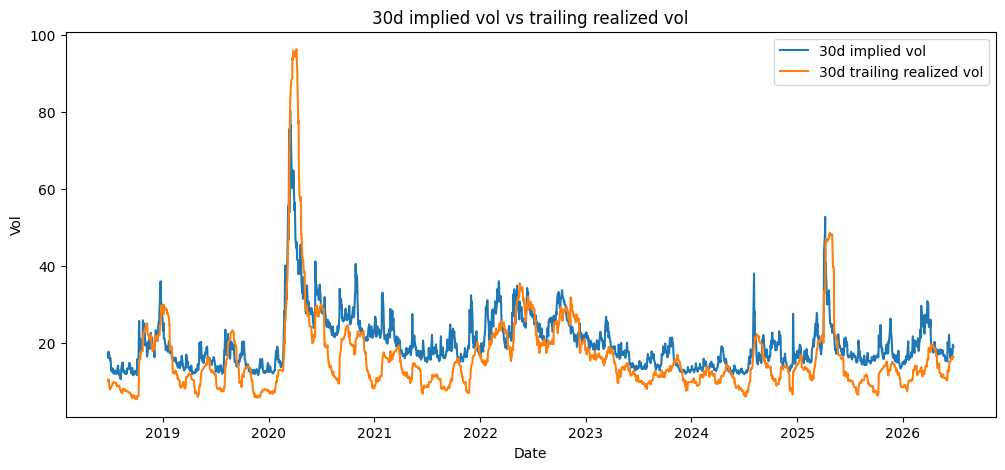

In [34]:
# ============================================================
# Plot 30d implied vol vs trailing realized vol only
# ============================================================

plot_30d_df = vrp_df[vrp_df["target_days"] == 30].copy()
plot_30d_df["date"] = pd.to_datetime(plot_30d_df["trade_date"].astype(str))

plt.figure(figsize=(12, 5))
plt.plot(plot_30d_df["date"], plot_30d_df["vix_style_vol"], label="30d implied vol")
plt.plot(plot_30d_df["date"], plot_30d_df["trailing_realized_vol"], label="30d trailing realized vol")
plt.title("30d implied vol vs trailing realized vol")
plt.xlabel("Date")
plt.ylabel("Vol")
plt.legend()
plt.show()

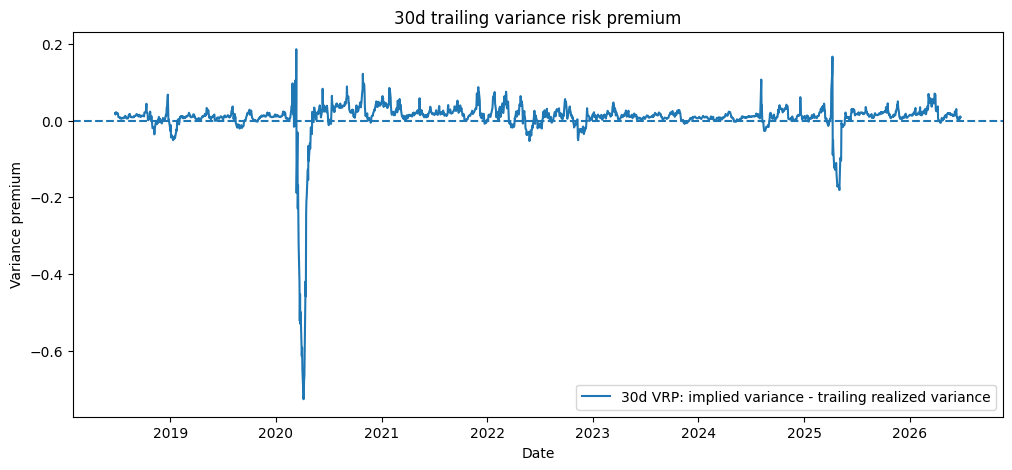

In [35]:
# ============================================================
# Plot 30d trailing VRP
# ============================================================

plt.figure(figsize=(12, 5))
plt.plot(
    plot_30d_df["date"],
    plot_30d_df["vrp_trailing_variance"],
    label="30d VRP: implied variance - trailing realized variance",
)
plt.axhline(0, linestyle="--")
plt.title("30d trailing variance risk premium")
plt.xlabel("Date")
plt.ylabel("Variance premium")
plt.legend()
plt.show()

In [36]:
# ============================================================
# Add 14-day SPX RSI using Wilder's smoothing
# ============================================================

def calculate_wilder_rsi(price_series, window=14):
    """
    Standard Wilder RSI.

    Uses price changes over trading observations.
    window=14 means 14 trading-day RSI, the market standard.
    """
    delta = price_series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    # Wilder smoothing is equivalent to EMA with alpha = 1/window
    avg_gain = gain.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()
    avg_loss = loss.ewm(alpha=1 / window, adjust=False, min_periods=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))

    return rsi


spx_feature_df = spx_df.copy()

spx_feature_df["spx_rsi_14"] = calculate_wilder_rsi(
    spx_feature_df["spx_close"],
    window=14,
)

spx_feature_df = spx_feature_df[
    [
        "trade_date",
        "spx_close",
        "log_return",
        "spx_rsi_14",
    ]
].rename(columns={
    "log_return": "spx_log_return",
})

display(spx_feature_df.head(25))
display(spx_feature_df.tail())

,trade_date,spx_close,spx_log_return,spx_rsi_14
0,20160627,2000.54,NaN,NaN
1,20160628,2036.09,0.017614,NaN
2,20160629,2070.77,0.016889,NaN
3,20160630,2098.86,0.013474,NaN
4,20160701,2102.95,0.001947,NaN
5,20160705,2088.55,-0.006871,NaN
6,20160706,2099.73,0.005339,NaN
7,20160707,2097.90,-0.000872,NaN
8,20160708,2129.90,0.015138,NaN
9,20160711,2137.16,0.003403,NaN


,trade_date,spx_close,spx_log_return,spx_rsi_14
2509,20260622,7472.79,-0.003712,53.235432
2510,20260623,7365.46,-0.014467,46.752076
2511,20260624,7358.22,-0.000983,46.342083
2512,20260625,7357.49,-0.000099,46.297996
2513,20260626,7354.02,-0.000472,46.073621


In [38]:
# ============================================================
# Join SPX RSI into VRP panel
# ============================================================

# If the columns already exist from a prior run, drop them before rejoining
cols_to_drop = [
    "spx_close",
    "spx_log_return",
    "spx_rsi_14",
]

vrp_df = vrp_df.drop(columns=[c for c in cols_to_drop if c in vrp_df.columns])

vrp_df = vrp_df.merge(
    spx_feature_df,
    on="trade_date",
    how="left",
    validate="many_to_one",
)

print("Rows:", len(vrp_df))
print("Missing SPX close:", vrp_df["spx_close"].isna().sum())
print("Missing SPX RSI 14:", vrp_df["spx_rsi_14"].isna().sum())

display(
    vrp_df[
        [
            "trade_date",
            "target_days",
            "vix_style_vol",
            "trailing_realized_vol",
            "vrp_trailing_log_variance_ratio",
            "spx_close",
            "spx_rsi_14",
        ]
    ].head(30)
)

Rows: 18099
Missing SPX close: 0
Missing SPX RSI 14: 0


KeyError: "['vrp_trailing_log_variance_ratio'] not in index"

In [40]:
# ============================================================
# Create relative VRP columns, confirm RSI, display, and save
# ============================================================

# Relative VRP measures
vrp_df["vrp_trailing_variance_ratio"] = (
    vrp_df["implied_variance"]
    / vrp_df["trailing_realized_variance"].replace(0, np.nan)
)

vrp_df["vrp_trailing_log_variance_ratio"] = np.log(
    vrp_df["vrp_trailing_variance_ratio"]
)

vrp_df["vrp_trailing_vol_ratio"] = (
    vrp_df["vix_style_vol"]
    / vrp_df["trailing_realized_vol"].replace(0, np.nan)
)

# Main signal input for notebook 06
vrp_df["primary_vrp_signal"] = vrp_df["vrp_trailing_log_variance_ratio"]

# Clean infinite values
relative_vrp_cols = [
    "vrp_trailing_variance_ratio",
    "vrp_trailing_log_variance_ratio",
    "vrp_trailing_vol_ratio",
    "primary_vrp_signal",
]

for col in relative_vrp_cols:
    vrp_df[col] = vrp_df[col].replace([np.inf, -np.inf], np.nan)

print("Rows:", len(vrp_df))
print("Missing SPX close:", vrp_df["spx_close"].isna().sum())
print("Missing SPX RSI 14:", vrp_df["spx_rsi_14"].isna().sum())
print("Missing variance ratio:", vrp_df["vrp_trailing_variance_ratio"].isna().sum())
print("Missing log variance ratio:", vrp_df["vrp_trailing_log_variance_ratio"].isna().sum())
print("Missing vol ratio:", vrp_df["vrp_trailing_vol_ratio"].isna().sum())
print("Missing primary signal:", vrp_df["primary_vrp_signal"].isna().sum())

display(
    vrp_df[
        [
            "trade_date",
            "target_days",
            "vix_style_vol",
            "trailing_realized_vol",
            "vrp_trailing_variance_ratio",
            "vrp_trailing_log_variance_ratio",
            "vrp_trailing_vol_ratio",
            "primary_vrp_signal",
            "spx_close",
            "spx_rsi_14",
        ]
    ].head(30)
)

# Save updated panel
VRP_PANEL_CSV = PROCESSED_DATA_DIR / "vrp_panel_v0_1.csv"
VRP_PANEL_PARQUET = PROCESSED_DATA_DIR / "vrp_panel_v0_1.parquet"

vrp_df.to_csv(VRP_PANEL_CSV, index=False)
vrp_df.to_parquet(VRP_PANEL_PARQUET, index=False)

print("\nSaved VRP CSV:", VRP_PANEL_CSV)
print("Saved VRP parquet:", VRP_PANEL_PARQUET)

Rows: 18099
Missing SPX close: 0
Missing SPX RSI 14: 0
Missing variance ratio: 0
Missing log variance ratio: 0
Missing vol ratio: 0
Missing primary signal: 0


,trade_date,target_days,vix_style_vol,trailing_realized_vol,vrp_trailing_variance_ratio,vrp_trailing_log_variance_ratio,vrp_trailing_vol_ratio,primary_vrp_signal,spx_close,spx_rsi_14
0,20180625,9,17.348587,10.242504,2.868903,1.053930,1.693784,1.053930,2717.07,41.761584
1,20180625,12,17.490509,8.991663,3.783771,1.330721,1.945192,1.330721,2717.07,41.761584
2,20180625,15,17.490890,8.346020,4.392027,1.479791,2.095716,1.479791,2717.07,41.761584
3,20180625,18,17.491144,7.747385,5.097135,1.628679,2.257684,1.628679,2717.07,41.761584
4,20180625,21,17.426522,8.016921,4.725048,1.552878,2.173718,1.552878,2717.07,41.761584
5,20180625,24,17.377898,7.699049,5.094720,1.628205,2.257149,1.628205,2717.07,41.761584
6,20180625,27,17.349740,9.817784,3.122907,1.138764,1.767175,1.138764,2717.07,41.761584
7,20180625,30,17.330003,10.159268,2.909862,1.068106,1.705832,1.068106,2717.07,41.761584
8,20180625,33,17.335065,9.741543,3.166617,1.152664,1.779499,1.152664,2717.07,41.761584
9,20180626,9,15.359305,10.338066,2.207316,0.791777,1.485704,0.791777,2723.06,43.759005



Saved VRP CSV: C:\Users\patri\vrp_project\data\processed\vrp_panel_v0_1.csv
Saved VRP parquet: C:\Users\patri\vrp_project\data\processed\vrp_panel_v0_1.parquet


In [41]:
# ============================================================
# Display VRP panel with RSI and relative VRP
# ============================================================

display(
    vrp_df[
        [
            "trade_date",
            "target_days",
            "vix_style_vol",
            "trailing_realized_vol",
            "vrp_trailing_variance_ratio",
            "vrp_trailing_log_variance_ratio",
            "vrp_trailing_vol_ratio",
            "primary_vrp_signal",
            "spx_close",
            "spx_rsi_14",
        ]
    ].head(30)
)

,trade_date,target_days,vix_style_vol,trailing_realized_vol,vrp_trailing_variance_ratio,vrp_trailing_log_variance_ratio,vrp_trailing_vol_ratio,primary_vrp_signal,spx_close,spx_rsi_14
0,20180625,9,17.348587,10.242504,2.868903,1.053930,1.693784,1.053930,2717.07,41.761584
1,20180625,12,17.490509,8.991663,3.783771,1.330721,1.945192,1.330721,2717.07,41.761584
2,20180625,15,17.490890,8.346020,4.392027,1.479791,2.095716,1.479791,2717.07,41.761584
3,20180625,18,17.491144,7.747385,5.097135,1.628679,2.257684,1.628679,2717.07,41.761584
4,20180625,21,17.426522,8.016921,4.725048,1.552878,2.173718,1.552878,2717.07,41.761584
5,20180625,24,17.377898,7.699049,5.094720,1.628205,2.257149,1.628205,2717.07,41.761584
6,20180625,27,17.349740,9.817784,3.122907,1.138764,1.767175,1.138764,2717.07,41.761584
7,20180625,30,17.330003,10.159268,2.909862,1.068106,1.705832,1.068106,2717.07,41.761584
8,20180625,33,17.335065,9.741543,3.166617,1.152664,1.779499,1.152664,2717.07,41.761584
9,20180626,9,15.359305,10.338066,2.207316,0.791777,1.485704,0.791777,2723.06,43.759005


In [42]:
# ============================================================
# Save updated VRP panel with relative VRP and SPX RSI
# ============================================================

VRP_PANEL_CSV = PROCESSED_DATA_DIR / "vrp_panel_v0_1.csv"
VRP_PANEL_PARQUET = PROCESSED_DATA_DIR / "vrp_panel_v0_1.parquet"

vrp_df.to_csv(VRP_PANEL_CSV, index=False)
vrp_df.to_parquet(VRP_PANEL_PARQUET, index=False)

print("Saved VRP CSV:", VRP_PANEL_CSV)
print("Saved VRP parquet:", VRP_PANEL_PARQUET)

print("Rows:", len(vrp_df))
print("Columns added/confirmed:")
print("  spx_close")
print("  spx_log_return")
print("  spx_rsi_14")
print("  vrp_trailing_variance_ratio")
print("  vrp_trailing_log_variance_ratio")
print("  vrp_trailing_vol_ratio")
print("  primary_vrp_signal")

Saved VRP CSV: C:\Users\patri\vrp_project\data\processed\vrp_panel_v0_1.csv
Saved VRP parquet: C:\Users\patri\vrp_project\data\processed\vrp_panel_v0_1.parquet
Rows: 18099
Columns added/confirmed:
  spx_close
  spx_log_return
  spx_rsi_14
  vrp_trailing_variance_ratio
  vrp_trailing_log_variance_ratio
  vrp_trailing_vol_ratio
  primary_vrp_signal
